In [1]:
#pip install tensorflow


In [2]:
#pip install pandas numpy matplotlib scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# 1. Load dữ liệu
df = pd.read_csv("../../data/processed/training_data_final (only Gold).csv", parse_dates=["Datetime"], index_col="Datetime")

# Chọn cột GOLD để dự đoán
data = df[["Gold"]]

In [5]:
# 2. Tiền xử lí dữ liệu
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [6]:
# 3. Tạo tập dữ liệu huấn luyện và kiểm tra
X, y = [], []
window = 60  # 60 phút trước

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])  
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [7]:
# 4.Reshape dữ liệu cho LSTM (3D)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
# Chia train/test theo thời gian
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [8]:
# 5.Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# 6. Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 291s 128ms/step - loss: 0.0016 - val_loss: 5.1911e-10
Epoch 2/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 249s 94ms/step - loss: 7.5061e-05 - val_loss: 2.1083e-06
Epoch 3/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 189s 87ms/step - loss: 6.6123e-05 - val_loss: 1.0524e-06
Epoch 4/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 192s 83ms/step - loss: 5.3975e-05 - val_loss: 7.6000e-07
Epoch 5/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 148s 58ms/step - loss: 3.5942e-05 - val_loss: 1.8598e-08
Epoch 6/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 138s 56ms/step - loss: 3.2704e-05 - val_loss: 1.9960e-08
Epoch 7/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 143s 57ms/step - loss: 3.4733e-05 - val_loss: 2.1100e-08
Epoch 8/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 141s 56ms/step - loss: 2.3441e-05 - val_loss: 2.5205e-06
Epoch 9/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 166s 68ms/step - loss: 2.3237e-05 - val_loss: 1.7822e-08
Epoch 10/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 122s 57ms/step - loss: 2.2579e-05 - val_loss: 1.8674e-09
Epoch 11/20


In [10]:
# 7. Dự đoán
y_pred_scaled = model.predict(X_test)

# Chuyển từ [0,1] về giá thật
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


594/594 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


In [11]:
# 8. Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 0.003655394996945866
R² score: 0.9987174735469385


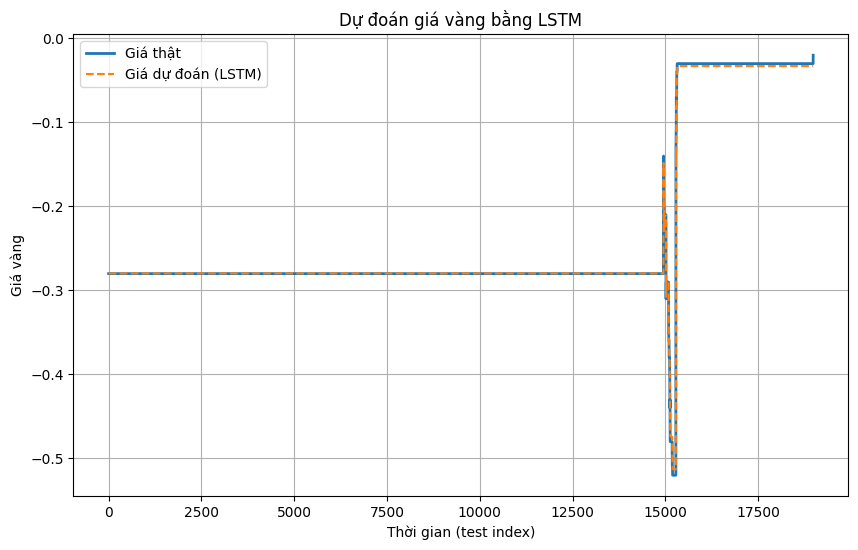

In [12]:
# 9. Vẽ biểu đồ dự đoán
plt.figure(figsize=(10,6))
plt.plot(y_test_real, label="Giá thật", linewidth=2)
plt.plot(y_pred, label="Giá dự đoán (LSTM)", linestyle='--')
plt.title("Dự đoán giá vàng bằng LSTM")
plt.xlabel("Thời gian (test index)")
plt.ylabel("Giá vàng")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# 1. Lấy lại mốc thời gian (Datetime) từ dữ liệu gốc
# Logic: Lấy n dòng cuối cùng của df, với n bằng đúng độ dài của tập test
test_dates = df.index[-len(y_test):]

# 2. Tạo DataFrame (Lưu ý: y_test và y_pred đang là mảng, nên cần .flatten() để duỗi thẳng ra)
result_df = pd.DataFrame({
    'Datetime': test_dates,
    # Lưu ý: Nên lưu giá thực (đã inverse_transform) để so sánh cho dễ.
    # Nếu bạn dùng biến y_test (đang scale 0-1) thì so sánh sẽ khó.
    # Giả sử y_test_inv và test_predict là biến chứa giá USD thật bạn đã tạo ở trên:
    'Actual': y_test_inv.flatten(),
    'Predicted': test_predict.flatten()
})

# 3. Lưu ra file CSV
import os
os.makedirs('../../results/predictions', exist_ok=True)
result_df.to_csv('../../results/predictions/LSTM.csv', index=False)

print("✅ Đã lưu kết quả dự báo của LSTM thành công!")
print(result_df.head())

NameError: name 'y_test_inv' is not defined